In [1]:
# limit the thread used by numpy 
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"  

import numpy as np
from scipy.interpolate import interp1d 
from scipy.signal import savgol_filter

from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
# import matplotlib
# matplotlib.rcParams['text.usetex'] = True
# matplotlib.rcParams['font.family'] = 'serif'

from Triangle.Constants import *
from Triangle.Orbit import * 
from Triangle.Noise import *
from Triangle.FFTTools import *
from Triangle.TDI import *
from Triangle.Data import * 

from Triangle_BBH.Waveform import WaveformGeneratorFRef
from Triangle_BBH.Response import FDTDIResponseGeneratorFRef
from Triangle_BBH.Utils import * 
from Triangle_BBH.Fisher import *

import multiprocessing
if __name__=='__main__':
    multiprocessing.set_start_method("fork")
    
import bilby 

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


no cupy 
no cupy
No CuPy or GPU PhenomHM module.
has BBHx waveform


## Load TDC data 

In [2]:
h5filename = "/Users/taijidatacenter/workspace/TDCData/0_2_MBHB_TDIXYZ.h5"
with h5py.File(h5filename, "r") as h5file: 
    data_dict = read_dict_from_h5(h5file["/"])

h5paramfilename = "/Users/taijidatacenter/workspace/TDCData/0_2_MBHB_parameters.h5"
with h5py.File(h5paramfilename, "r") as h5file: 
    fiducial_parameters = read_dict_from_h5(h5file["/"])

data_dict, fiducial_parameters

({'XYZ': {'X2': array([0., 0., 0., ..., 0., 0., 0.]),
   'Y2': array([0., 0., 0., ..., 0., 0., 0.]),
   'Z2': array([0., 0., 0., ..., 0., 0., 0.])},
  'time': array([0.00000e+00, 1.00000e+01, 2.00000e+01, ..., 2.59197e+06,
         2.59198e+06, 2.59199e+06])},
 {'chirp_mass': 3000000.0,
  'coalescence_phase': 1.0471975511965976,
  'coalescence_time': 25.0,
  'inclination': 1.2566370614359172,
  'latitude': 0.5235987755982988,
  'longitude': 4.71238898038469,
  'luminosity_distance': 47689.47472418477,
  'mass_ratio': 0.25,
  'psi': 0.9424777960769379,
  'spin_1z': 0.4,
  'spin_2z': 0.6})

## Slice data 

In [3]:
start_time = 20. * DAY 
Tobs = 7. * DAY 
dt = data_dict["time"][1] - data_dict["time"][0]
end_time = start_time + Tobs

slice_idx = np.where((data_dict["time"]>=start_time)&(data_dict["time"]<=end_time))[0]
data_time = data_dict["time"][slice_idx]
data_channels_td = np.array(AETfromXYZ(
    data_dict["XYZ"]["X2"][slice_idx], 
    data_dict["XYZ"]["Y2"][slice_idx], 
    data_dict["XYZ"]["Z2"][slice_idx]
    ))
data_channels_td = -data_channels_td # NOTE: due to our convension for TDI channel in the FDResponse model

channel_names = ["A", "E", "T"]
channel_colors = [RED, BLUE, ORANGE]

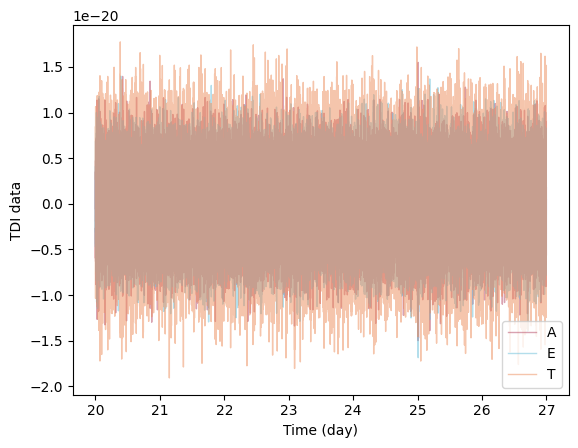

In [4]:
for i in range(3): 
    plt.plot(data_time / DAY, data_channels_td[i], linewidth=1, color=channel_colors[i], label=channel_names[i], alpha=0.5)
plt.xlabel("Time (day)")
plt.ylabel("TDI data")
plt.legend()

## Fourier transform

In [5]:
data_channels_fd = [] 
for i in range(3): 
    ff, xf = FFT_window(
        data_array=data_channels_td[i], 
        fsample=1./dt, 
        window_type="tukey", 
        window_args_dict=dict(alpha=0.05)
        )
    data_channels_fd.append(xf * np.exp(-TWOPI * 1.j * ff * start_time)) 
data_channels_fd = np.array(data_channels_fd)
data_frequency = ff 

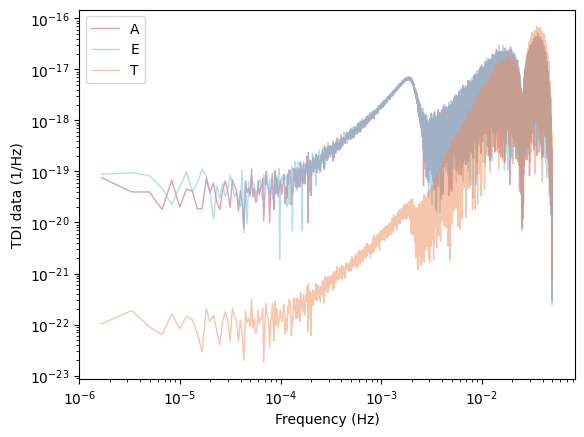

In [6]:
for i in range(3): 
    plt.loglog(data_frequency, np.abs(data_channels_fd[i]), color=channel_colors[i], label=channel_names[i], linewidth=1, alpha=0.5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("TDI data (1/Hz)")
plt.legend()

## Select target frequency band 

In [7]:
fmin = 5e-5 
fmax = 1e-2 
freq_idx = np.where((data_frequency>=fmin+1e-4)&(data_frequency<=fmax-1e-4))[0]
data_frequency = data_frequency[freq_idx]
data_channels_fd = data_channels_fd[:, freq_idx]

## Noise characterization 

In [8]:
Tasd = 1. * DAY 
data_before_idx = np.where((data_dict["time"]<=start_time)&(data_dict["time"]>=start_time-Tasd))[0]
data_before = np.array(AETfromXYZ(data_dict["XYZ"]["X2"][data_before_idx], data_dict["XYZ"]["Y2"][data_before_idx], data_dict["XYZ"]["Z2"][data_before_idx]))
psd_before = []
for i in range(3): 
    ff, xf = PSD_window(
        data_array=data_before[i], 
        fsample=1./dt, 
        nbin=1, 
        window_type="hann", 
    )
    psd_before.append(xf)
psd_before = np.array(psd_before)
psd_freq = ff 

data_after_idx = np.where((data_dict["time"]<=end_time+Tasd)&(data_dict["time"]>=end_time))[0]
data_after = np.array(AETfromXYZ(data_dict["XYZ"]["X2"][data_after_idx], data_dict["XYZ"]["Y2"][data_after_idx], data_dict["XYZ"]["Z2"][data_after_idx]))
psd_after = []
for i in range(3): 
    ff, xf = PSD_window(
        data_array=data_after[i], 
        fsample=1./dt, 
        nbin=1, 
        window_type="hann", 
    )
    psd_after.append(xf)
psd_after = np.array(psd_after)

psd_channels = (psd_before + psd_after) / 2. 

freq_idx = np.where((psd_freq>=fmin)&(psd_freq<=fmax))[0]
psd_freq = psd_freq[freq_idx]
psd_channels = psd_channels[:, freq_idx]

psd_channels_smooth = np.zeros_like(psd_channels)
for i in range(3): 
    psd_channels_smooth[i] = savgol_filter(psd_channels[i], window_length=51, polyorder=3)

In [9]:
psd_func_A = interp1d(x=psd_freq, y=psd_channels_smooth[0])
psd_func_E = interp1d(x=psd_freq, y=psd_channels_smooth[1])
psd_func_T = interp1d(x=psd_freq, y=psd_channels_smooth[2])

# covariance matrix 
CovMat = np.array([
    [psd_func_A(data_frequency), np.zeros_like(data_frequency), np.zeros_like(data_frequency)],
    [np.zeros_like(data_frequency), psd_func_E(data_frequency), np.zeros_like(data_frequency)],
    [np.zeros_like(data_frequency), np.zeros_like(data_frequency), psd_func_T(data_frequency)]
]) / 4. * Tobs # (3, 3, Nf)

# inverse of covmatrix
InvCovMat = np.linalg.inv(np.transpose(CovMat, (2, 0, 1))) # (Nf, 3, 3)

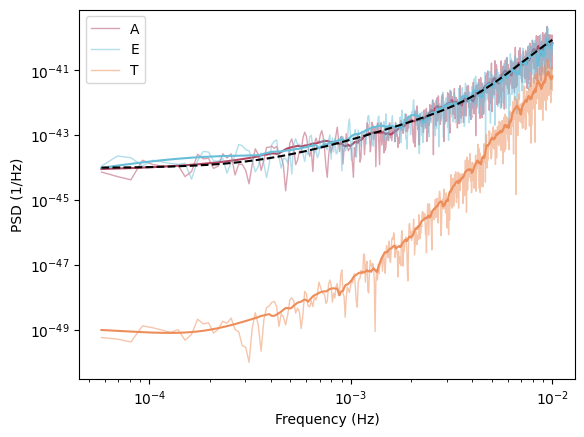

In [10]:
for i in range(3): 
    plt.loglog(psd_freq, psd_channels[i], label=channel_names[i], color=channel_colors[i], linewidth=1, alpha=0.5)
    plt.loglog(psd_freq, psd_channels_smooth[i], color=channel_colors[i])
psdfunc = TDIPSDs()
plt.loglog(psd_freq, psdfunc.PSD_A2(psd_freq), linestyle="--", color="k")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (1/Hz)")
plt.legend()

## Response model 

In [11]:
# the path of Taiji orbit 
orbit = Orbit(
    OrbitDir="../../Triangle-Simulator/OrbitData/MicroSateOrbitEclipticTCB", 
    ) 

# initialize  waveform generator 
WFG = WaveformGeneratorFRef(
    mode="primary", 
)

# initialize response generator 
FDTDI = FDTDIResponseGeneratorFRef(
    orbit_class=orbit, 
    waveform_generator=WFG, 
)

# response settings 
response_kwargs_interp = dict(
    fmin=fmin, # used to calculate freq grid
    fmax=fmax, # used to calculate freq grid
    fref=1e-3, # used to set reference point 
    Nfreqs=1024, # used to calculate freq grid
    modes=[(2, 2)], 
    tmin=start_time/DAY, # minimum time of orbit in day 
    tmax=end_time/DAY, # maximum time of orbit in day
    tref_at_constellation=True, # whether tc is the coalescence time at constellation center (True) or SSB (False)
    TDIGeneration='2nd',
    optimal_combination=True,
    interpolation_method='cubic',
    output_by_mode=False, 
)

response_kwargs_direct = dict(
    fref=1e-3, # used to set reference point 
    modes=[(2, 2)], 
    tmin=start_time/DAY, # minimum time of orbit in day 
    tmax=end_time/DAY, # maximum time of orbit in day
    tref_at_constellation=True, # whether tc is the coalescence time at constellation center (True) or SSB (False)
    TDIGeneration='2nd',
    optimal_combination=True,
    interpolation_method=None, 
    output_by_mode=False, 
)

In [12]:
test_parameters = fiducial_parameters.copy() 
test_parameters["reference_time"] = fiducial_parameters["coalescence_time"]
test_parameters["reference_phase"] = fiducial_parameters["coalescence_phase"]

wf_channels = FDTDI.Response(
    test_parameters, 
    data_frequency, 
    **response_kwargs_direct
)

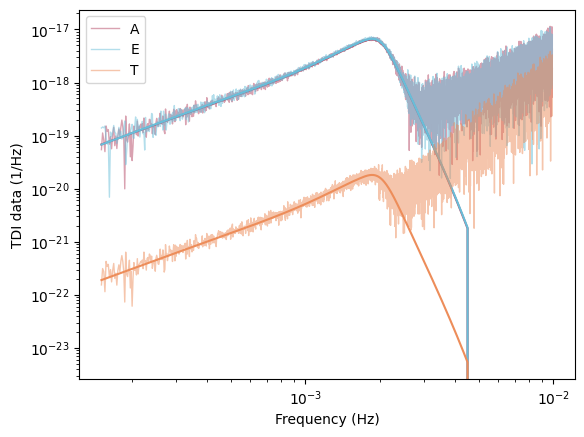

In [13]:
for i in range(3): 
    plt.loglog(data_frequency, np.abs(data_channels_fd[i]), color=channel_colors[i], label=channel_names[i], linewidth=1, alpha=0.5)
    plt.loglog(data_frequency, np.abs(wf_channels[i]), color=channel_colors[i])
plt.xlabel("Frequency (Hz)")
plt.ylabel("TDI data (1/Hz)")
plt.legend()

## MLE with  $\mathcal{F}$-stat 

### initialize F-stat 

In [14]:
Fstat = FstatisticsFref(
    response_generator=FDTDI, 
    frequency=data_frequency, 
    data=data_channels_fd, 
    invserse_covariance_matrix=InvCovMat, 
    response_parameters=response_kwargs_interp, 
    use_gpu=False
)

### set priors 

In [15]:
lgMc_prior = [5., 7.]
q_prior = [0.1, 1]
s1_prior = [-0.9, 0.9]
s2_prior = [-0.9, 0.9]
tref_prior = [start_time / DAY, end_time / DAY] 
lam_prior = [0, TWOPI]
sinbeta_prior = [-1., 1.]
intrinsic_param_priors = np.array([
    lgMc_prior, 
    q_prior, 
    s1_prior, 
    s2_prior, 
    tref_prior, 
    lam_prior, 
    sinbeta_prior, 
])

### optimization from prior 

In [16]:
from scipy.optimize import differential_evolution

def cost_function(norm_int_params):
    """   
        norm_int_params: shape (Nparams), normalized to (0, 1)
    """
    int_params = norm_int_params * (intrinsic_param_priors[:, 1] - intrinsic_param_priors[:, 0]) + intrinsic_param_priors[:, 0] # (Nparams)
    params_in = Fstat.IntParamArr2ParamDict(int_params) # (Nparams) -> dictionary
    return -Fstat.calculate_Fstat(intrinsic_parameters=params_in) # float

n_dim_int = 7 
lower_bounds = np.zeros(n_dim_int) 
upper_bounds = np.ones(n_dim_int) 
bounds = np.array([lower_bounds, upper_bounds]).T # (Nparams, 2)

DE_result = differential_evolution(
    func=cost_function,
    bounds=bounds,
    x0=None,
    strategy='best1exp',
    # strategy='rand1bin',
    maxiter=5000,
    popsize=10*n_dim_int,
    # popsize=6*n_dim_int, 
    tol=1e-7,
    atol=1e-9,
    mutation=(0.4, 0.95),
    recombination=0.7,
    disp=False,
    polish=True,
    # vectorized=True,
    workers=-1, 
)

/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/WF4Py/waveform_models/IMRPhenomHM.py:305: RuntimeWarning: invalid value encountered in sqrt
  fpeak = np.where(gamma2 >= 1.0, np.fabs(fring - (fdamp*gamma3)/gamma2), fring + (fdamp*(-1.0 + np.sqrt(1.0 - gamma2*gamma2))*gamma3)/gamma2)
/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/WF4Py/waveform_models/IMRPhenomHM.py:199: RuntimeWarning: invalid value encountered in sqrt
  fpeak = np.where(gamma2 >= 1.0, np.fabs(fring - (fdamp*gamma3)/gamma2), np.fabs(fring + (fdamp*(-1.0 + np.sqrt(1.0 - gamma2*gamma2))*gamma3)/gamma2))
/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/WF4Py/waveform_models/IMRPhenomHM.py:305: RuntimeWarning: invalid value encountered in sqrt
  fpeak = np.where(gamma2 >= 1.0, np.fabs(fring - (fdamp*gamma3)/gamma2), fring + (fdamp*(-1.0 + np.sqrt(1.0 - gamma2*gamma2))*gamma3)/gamma2)
/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/

In [17]:
print(DE_result)

             message: Optimization terminated successfully.
             success: True
                 fun: -710113.9807063278
                   x: [ 7.383e-01  1.682e-01  7.149e-01  8.615e-01
                        7.139e-01  7.414e-01  6.261e-01]
                 nit: 198
                nfev: 97542
          population: [[ 7.383e-01  1.682e-01 ...  7.414e-01  6.261e-01]
                       [ 7.383e-01  1.681e-01 ...  7.455e-01  6.177e-01]
                       ...
                       [ 7.383e-01  1.684e-01 ...  7.412e-01  6.249e-01]
                       [ 7.383e-01  1.680e-01 ...  7.428e-01  6.211e-01]]
 population_energies: [-7.101e+05 -7.101e+05 ... -7.101e+05 -7.101e+05]
                 jac: [ 1.126e+02  4.608e+01  1.609e+01 -2.515e+00
                       -6.232e+02  7.334e-01  1.281e-01]


### reconstruct parameters and waveforms 

In [18]:
searched_int_params = Fstat.IntParamArr2ParamDict(DE_result.x * (intrinsic_param_priors[:, 1] - intrinsic_param_priors[:, 0]) + intrinsic_param_priors[:, 0])

searched_a = Fstat.calculate_Fstat(
    intrinsic_parameters=searched_int_params, 
    return_a=True, 
) # (1, 4)
searched_ext_params = Fstat.a_to_extrinsic(searched_a)

searched_params = dict(searched_int_params, **searched_ext_params)
searched_reflect_params = get_reflected_parameter_dict_Fref(searched_params, orbit)

searched_params

{'chirp_mass': 2996310.3695820263,
 'mass_ratio': 0.2513509552781189,
 'spin_1z': 0.3868961771646967,
 'spin_2z': 0.6506851697110966,
 'reference_time': 24.9976222802416,
 'longitude': 4.658356151637749,
 'latitude': 0.2549217765335527,
 'luminosity_distance': 44137.272180301516,
 'inclination': 1.2567323384681055,
 'psi': 2.520887568285982,
 'reference_phase': 2.992187051370699}

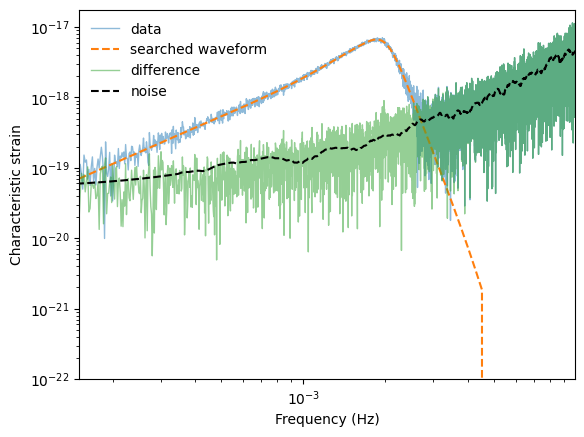

In [19]:
searched_wf1 = FDTDI.Response(
    searched_params, 
    data_frequency, 
    **response_kwargs_direct
)

k_fiducial = FDTDI.WaveVector(parameters=searched_params)
k_reflected = FDTDI.WaveVector(parameters=searched_reflect_params)
R1_tc = orbit.Positionfunctions()["1"](searched_params["reference_time"]*DAY)
R2_tc = orbit.Positionfunctions()["2"](searched_params["reference_time"]*DAY)
R3_tc = orbit.Positionfunctions()["3"](searched_params["reference_time"]*DAY)
R0_tc = (R1_tc + R2_tc + R3_tc) / 3. / C 
exp_factor_fiducial = np.exp(1.j * TWOPI * response_kwargs_interp["fref"] * np.dot(k_fiducial, R0_tc))
exp_factor_reflected = np.exp(1.j * TWOPI * response_kwargs_interp["fref"] * np.dot(k_reflected, R0_tc))

searched_wf2 = FDTDI.Response(
    searched_reflect_params, 
    data_frequency, 
    **response_kwargs_direct
) * exp_factor_reflected / exp_factor_fiducial

plt.loglog(data_frequency, np.abs(data_channels_fd[0]), label="data", linewidth=1, alpha=0.5)
plt.loglog(data_frequency, np.abs(searched_wf1[0]), linestyle="--", label="searched waveform")
# plt.loglog(data_frequency, np.abs(searched_wf2[0]), linestyle=":", label="searched waveform (reflected)")
plt.loglog(data_frequency, np.abs(searched_wf1[0] - data_channels_fd[0]), linestyle="-", linewidth=1, alpha=0.5, label="difference")
# plt.loglog(data_frequency, np.abs(searched_wf2[0] - data_channels_fd[0]), linestyle="-", linewidth=1, alpha=0.5, label="difference (reflected)")
plt.loglog(psd_freq, np.sqrt(psd_channels_smooth[0] * Tobs / 2.), label="noise", color="k", linestyle="--")
plt.ylim(1e-22, )
plt.xlim(data_frequency[0], data_frequency[-1])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Characteristic strain")
plt.legend(loc="upper left", frameon=False)

## Fisher analysis 

In [20]:
def fisher_waveform_wrapper(param_dict, frequencies):
    res = FDTDI.Response(
        parameters=param_dict, 
        freqs=frequencies,  
        **response_kwargs_interp, 
    )
    return res

# set initial steps 
analyze_param_step_dict = {
    'chirp_mass': 10.,
    'mass_ratio': 0.01,
    'spin_1z': 0.01,
    'spin_2z': 0.01,
    'reference_time': 0.001,
    'reference_phase': 0.01,
    'luminosity_distance': 10.,
    'inclination': 0.01,
    'longitude': 0.01,
    'latitude': 0.01,
    'psi': 0.01
    }
for k, v in analyze_param_step_dict.items():
    analyze_param_step_dict[k] = -v 

FIM = MultiChannelFisher(
    waveform_generator=fisher_waveform_wrapper, 
    param_dict=searched_params, 
    analyze_param_step_dict=analyze_param_step_dict, 
    frequency=data_frequency, 
    inverse_covariance=InvCovMat, 
    verbose=0,
)

FIM.auto_test_step()
FIM.calculate_Fisher()
FIM.calculate_errors() 

In [21]:
print("parameter name | true value | bias | bias (reflected) | confidence interval")
for k, v in searched_params.items():
    if k not in ["reference_time", "reference_phase"]:
        print(k, fiducial_parameters[k], np.abs(v-fiducial_parameters[k]), np.abs(searched_reflect_params[k]-fiducial_parameters[k]), FIM.param_errors[k])

parameter name | true value | bias | bias (reflected) | confidence interval
chirp_mass 3000000.0 3689.6304179737344 3689.6304179737344 2434.606321006197
mass_ratio 0.25 0.0013509552781189038 0.0013509552781189038 0.0012215993653260616
spin_1z 0.4 0.013103822835303314 0.013103822835303314 0.0074370244770924025
spin_2z 0.6 0.0506851697110966 0.0506851697110966 0.03394826153834713
longitude 4.71238898038469 0.05403282874694071 2.46849450963487 0.20417069976279573
latitude 0.5235987755982988 0.2686769990647461 1.25921727849581 0.22116330848177634
luminosity_distance 47689.47472418477 3552.202543883257 3552.202543883257 3118.275814748688
inclination 1.2566370614359172 9.527703218825678e-05 0.6282232536857704 0.0012697570021750631
psi 0.9424777960769379 1.578409772209044 0.6899205337616308 0.0934612339121222


## Nested sampling with bilby 

### Prior

In [22]:
priors = bilby.core.prior.PriorDict()
PRIOR_FACTOR = 5.
priors["chirp_mass"] = bilby.prior.Uniform(minimum=searched_params["chirp_mass"]-PRIOR_FACTOR*FIM.param_errors["chirp_mass"], maximum=searched_params["chirp_mass"]+PRIOR_FACTOR*FIM.param_errors["chirp_mass"], name='chirp_mass', latex_label='$\mathcal{M}_c$')
priors["mass_ratio"] = bilby.prior.Uniform(minimum=max(0.1, searched_params["mass_ratio"]-PRIOR_FACTOR*FIM.param_errors["mass_ratio"]), maximum=min(0.999, searched_params["mass_ratio"]+PRIOR_FACTOR*FIM.param_errors["mass_ratio"]), name="mass_ratio", latex_label='$q$')
priors["spin_1z"] = bilby.prior.Uniform(minimum=max(-0.9, searched_params["spin_1z"]-PRIOR_FACTOR*FIM.param_errors["spin_1z"]), maximum=min(0.9, searched_params["spin_1z"]+PRIOR_FACTOR*FIM.param_errors["spin_1z"]), name="spin_1z", latex_label='$\chi_{z1}$')
priors["spin_2z"] = bilby.prior.Uniform(minimum=max(-0.9, searched_params["spin_2z"]-PRIOR_FACTOR*FIM.param_errors["spin_2z"]), maximum=min(0.9, searched_params["spin_2z"]+PRIOR_FACTOR*FIM.param_errors["spin_2z"]), name="spin_2z", latex_label='$\chi_{z2}$')
priors["reference_time"] = bilby.prior.Uniform(minimum=searched_params["reference_time"]-PRIOR_FACTOR*FIM.param_errors["reference_time"], maximum=searched_params["reference_time"]+PRIOR_FACTOR*FIM.param_errors["reference_time"], name="reference_time", latex_label='$t_\mathrm{ref}$') 
priors["reference_phase"] = bilby.prior.Uniform(minimum=0., maximum=TWOPI, name="reference_phase", latex_label='$\\varphi_\mathrm{ref}$', boundary="periodic")
priors["luminosity_distance"] = bilby.prior.Uniform(minimum=max(1e4, searched_params["luminosity_distance"]-PRIOR_FACTOR*FIM.param_errors["luminosity_distance"]), maximum=min(1e5, searched_params["luminosity_distance"]+PRIOR_FACTOR*FIM.param_errors["luminosity_distance"]), name="luminosity_distance", latex_label='$d_L$')
priors["inclination"] = bilby.prior.Sine(minimum=0., maximum=PI, name="inclination", latex_label='$\iota$')
priors["longitude"] = bilby.prior.Uniform(minimum=0., maximum=TWOPI, name="longitude", latex_label='$\lambda$', boundary="periodic")
priors["latitude"] = bilby.prior.Cosine(minimum=-PI/2., maximum=PI/2., name="latitude", latex_label='$\\beta$')
priors["psi"] = bilby.prior.Uniform(minimum=0., maximum=PI, name="psi", latex_label='$\psi$', boundary="periodic")

priors

{'chirp_mass': Uniform(minimum=2984137.3379769954, maximum=3008483.401187057, name='chirp_mass', latex_label='$\\mathcal{M}_c$', unit=None, boundary=None),
 'mass_ratio': Uniform(minimum=0.2452429584514886, maximum=0.25745895210474923, name='mass_ratio', latex_label='$q$', unit=None, boundary=None),
 'spin_1z': Uniform(minimum=0.3497110547792347, maximum=0.4240812995501587, name='spin_1z', latex_label='$\\chi_{z1}$', unit=None, boundary=None),
 'spin_2z': Uniform(minimum=0.4809438620193609, maximum=0.8204264774028323, name='spin_2z', latex_label='$\\chi_{z2}$', unit=None, boundary=None),
 'reference_time': Uniform(minimum=24.997581525435397, maximum=24.997663035047804, name='reference_time', latex_label='$t_\\mathrm{ref}$', unit=None, boundary=None),
 'reference_phase': Uniform(minimum=0.0, maximum=6.283185307179586, name='reference_phase', latex_label='$\\varphi_\\mathrm{ref}$', unit=None, boundary='periodic'),
 'luminosity_distance': Uniform(minimum=28545.893106558076, maximum=59728.

### Likelihood

In [23]:
Like_direct = Likelihood(
    response_generator=FDTDI, 
    frequency=data_frequency, 
    data=data_channels_fd, 
    invserse_covariance_matrix=InvCovMat, 
    response_parameters=response_kwargs_direct, 
    Fref_waveform=True, 
    use_gpu=False, 
    verbose=0
)

fiducial_param_arr = ParamDict2ParamArrFref(searched_params)
Like_direct.prepare_het_log_like(base_parameters=fiducial_param_arr)

In [24]:
class bilby_likelihood_wrapper(bilby.Likelihood):
    def __init__(self, type="full"):
        super().__init__(
            parameters={
                'chirp_mass': None,
                'mass_ratio': None,
                'spin_1z': None,
                'spin_2z': None,
                'reference_time': None,
                'reference_phase': None,
                'luminosity_distance': None,
                'inclination': None,
                'longitude': None,
                'latitude': None,
                'psi': None
            }
        )
        
        if type == "full":
            self.likelihood = Like_direct.full_log_like 
        elif type == "het": 
            self.likelihood = Like_direct.het_log_like
        else: 
            raise ValueError("wrong likelihood type.")

    def log_likelihood(self):
        return self.likelihood(ParamDict2ParamArrFref(self.parameters))

In [25]:
BLike_het = bilby_likelihood_wrapper(type="het")

### sampling with het likelihood

In [26]:
import multiprocessing
ncpu = multiprocessing.cpu_count()
print("number of cpus =", ncpu)

result_het = bilby.run_sampler(
    likelihood=BLike_het, 
    priors=priors,
    sampler="nessai", 
    # sampler="dynesty", 
    nlive=1000, # dynesty / nessai 
    # walks=20, # dynesty 
    # nact=50, # dynesty 
    # maxmcmc=2000, # dynesty 
    stopping=0.5, # nessai 
    # dlogz=0.1, # dynesty 
    npool=ncpu, # use all cpus 
    injection_parameters=fiducial_parameters, 
    outdir="../../Samples",
    label="tribbh_example_vmbhb_het",
    plot=True,
    resume=False, 
    # resume=True, 
)

16:22 bilby INFO    : Running for label 'tribbh_example_vmbhb_het', output will be saved to '../../Samples'


number of cpus = 12


/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/bilby/core/utils/log.py:73: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  vdict[key] = str(getattr(sys.modules[key], "__version__", "N/A"))
16:22 bilby INFO    : Analysis priors:
16:22 bilby INFO    : chirp_mass=Uniform(minimum=2984137.3379769954, maximum=3008483.401187057, name='chirp_mass', latex_label='$\\mathcal{M}_c$', unit=None, boundary=None)
16:22 bilby INFO    : mass_ratio=Uniform(minimum=0.2452429584514886, maximum=0.25745895210474923, name='mass_ratio', latex_label='$q$', unit=None, boundary=None)
16:22 bilby INFO    : spin_1z=Uniform(minimum=0.3497110547792347, maximum=0.4240812995501587, name='spin_1z', latex_label='$\\chi_{z1}$', unit=None, boundary=None)
16:22 bilby INFO    : spin_2z=Uniform(minimum=0.4809438620193609, maximum=0.8204264774028323, name='spin_2z', latex_la

10-08 16:22 nessai INFO    : Running Nessai version 0.14.0.post0
10-08 16:22 nessai INFO    : Starting multiprocessing pool with 12 processes


/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/nessai/utils/logging.py:133: FutureWarning: setup_logger is deprecated, use configure_logger instead
  warnings.warn(


10-08 16:22 nessai INFO    : Initialising nested sampler
10-08 16:22 nessai WARNING : Multiprocessing pool has already been configured.
10-08 16:22 nessai WARNING : Removing unused keyword arguments ({'ensemble_fraction', 'n_steps', 'augment_dims', 'plot_chain', 'step_type', 'step_kwargs', 'marginalise_augment', 'enforce_likelihood_threshold', 'plot_history', 'max_n_clusters', 'n_marg', 'generate_augment', 'n_accept'}) from kwargs for FlowProposal. These are valid keyword arguments but correspond to other proposal classes.
10-08 16:22 nessai INFO    : Passing kwargs to FlowProposal: {'training_config': None, 'poolsize': 1000, 'check_acceptance': False, 'max_poolsize_scale': 10, 'update_poolsize': True, 'accumulate_weights': False, 'save_training_data': False, 'reparameterisations': None, 'fallback_reparameterisation': 'zscore', 'use_default_reparameterisations': None, 'reverse_reparameterisations': False, 'map_to_unit_hypercube': False, 'latent_prior': 'truncated_gaussian', 'constant_v

20:18 bilby INFO    : Sampling time: 3:56:46.215629
20:18 bilby INFO    : Summary of results:
nsamples: 1797
ln_noise_evidence:    nan
ln_evidence: 710073.444 +/-  0.187
ln_bayes_factor:    nan +/-  0.187



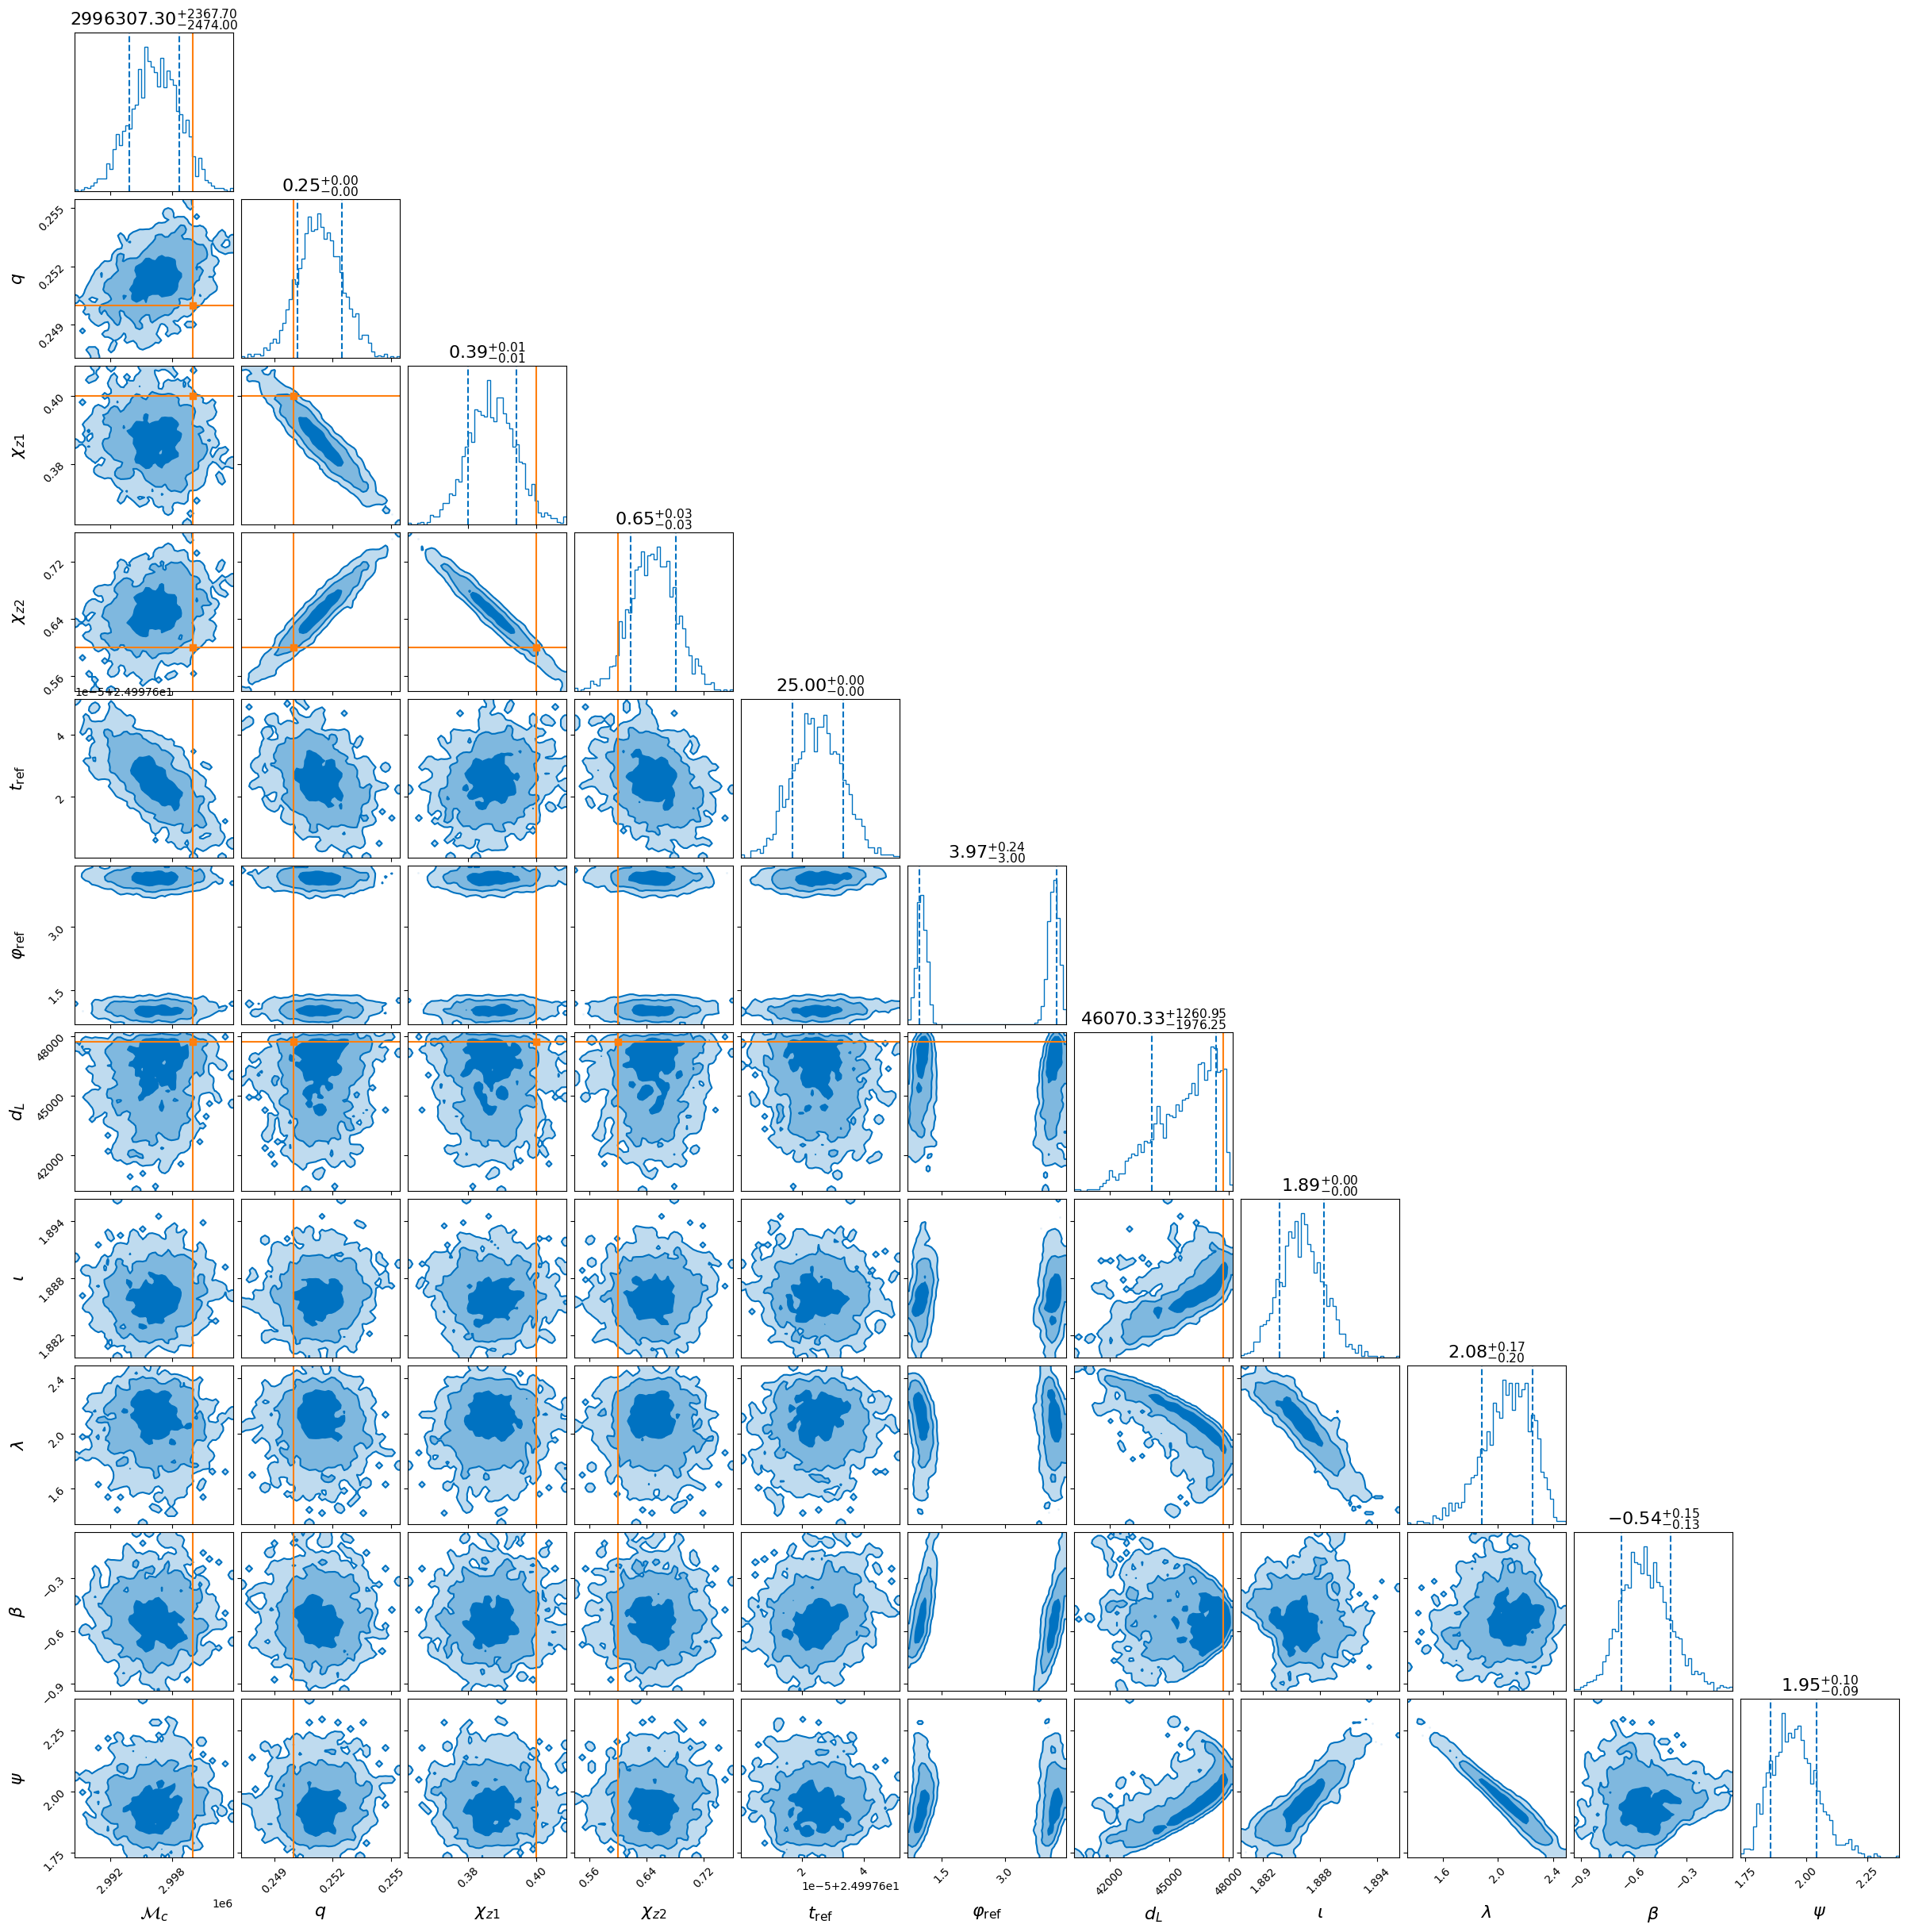

In [27]:
result_het.plot_corner(save=True)

In [32]:
for k, v in fiducial_parameters.items(): 
    if k not in ["coalescence_time", "coalescence_phase"]:
        print(k, v, searched_params[k], searched_reflect_params[k])

chirp_mass 3000000.0 2996310.3695820263 2996310.3695820263
inclination 1.2566370614359172 1.2567323384681055 1.8848603151216876
latitude 0.5235987755982988 0.2549217765335527 -0.7356185028975113
longitude 4.71238898038469 4.658356151637749 2.2438944707498196
luminosity_distance 47689.47472418477 44137.272180301516 44137.272180301516
mass_ratio 0.25 0.2513509552781189 0.2513509552781189
psi 0.9424777960769379 2.520887568285982 0.2525572623153072
spin_1z 0.4 0.3868961771646967 0.3868961771646967
spin_2z 0.6 0.6506851697110966 0.6506851697110966
